In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap

DATA_PATH  = "processed/floodsense_onset.csv"
MODELS_DIR = "final_models"
PLOTS_DIR  = "step5_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 80

In [2]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)

exclude_cols = ["date", "district", "flood_event", "flood_onset", "flood_state",
                "event_num", "event_id"]
feature_cols = [c for c in df.columns if c not in exclude_cols]
X_all = df[feature_cols].replace([np.inf, -np.inf], np.nan)

cont_model  = lgb.Booster(model_file=f"{MODELS_DIR}/lgb_continuation_final.txt")
onset_model = lgb.Booster(model_file=f"{MODELS_DIR}/lgb_onset_final.txt")
print(f"Loaded both production models. {len(feature_cols)} features.")

Loaded both production models. 53 features.


In [3]:
print("Building TreeSHAP explainers...")
explainer_cont  = shap.TreeExplainer(cont_model)
explainer_onset = shap.TreeExplainer(onset_model)

print("Computing SHAP values for continuation model...")
shap_values_cont  = explainer_cont.shap_values(X_all)
print("Computing SHAP values for onset model...")
shap_values_onset = explainer_onset.shap_values(X_all)

if isinstance(shap_values_cont, list):
    shap_values_cont = shap_values_cont[1]
if isinstance(shap_values_onset, list):
    shap_values_onset = shap_values_onset[1]

print(f"SHAP values shape — continuation: {shap_values_cont.shape}, onset: {shap_values_onset.shape}")

Building TreeSHAP explainers...
Computing SHAP values for continuation model...


/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Computing SHAP values for onset model...
SHAP values shape — continuation: (1365, 53), onset: (1365, 53)


/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


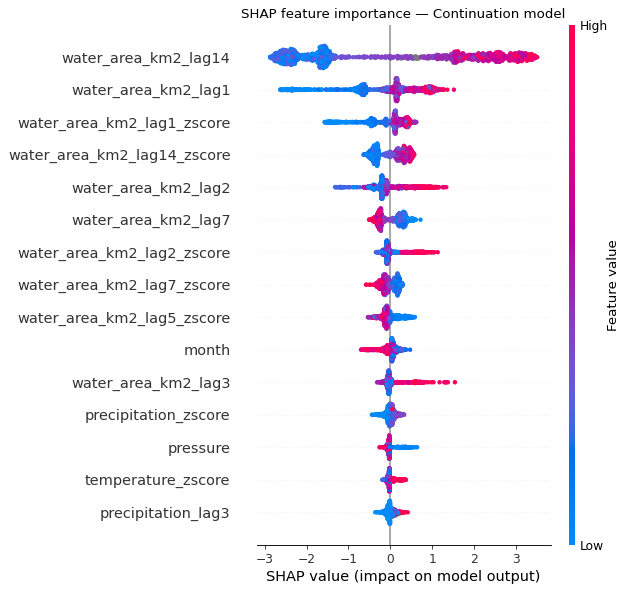

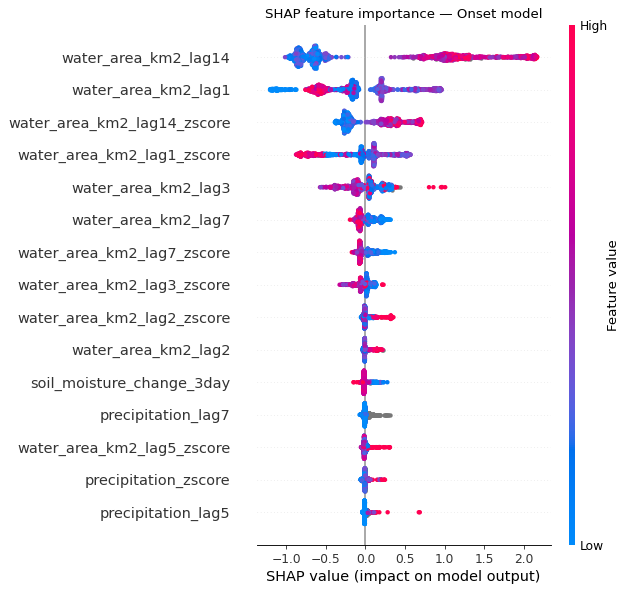

Saved step5_plots/shap_summary_continuation.png
Saved step5_plots/shap_summary_onset.png


In [4]:
def global_importance_plot(shap_values, X, name, out_path, top=15):
    fig = plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, feature_names=feature_cols,
                      max_display=top, show=False)
    plt.title(f"SHAP feature importance — {name} model")
    plt.tight_layout()
    plt.savefig(out_path, dpi=80, bbox_inches="tight")
    plt.show()
    plt.close()

global_importance_plot(shap_values_cont, X_all, "Continuation",
                        f"{PLOTS_DIR}/shap_summary_continuation.png")
global_importance_plot(shap_values_onset, X_all, "Onset",
                        f"{PLOTS_DIR}/shap_summary_onset.png")

print(f"Saved {PLOTS_DIR}/shap_summary_continuation.png")
print(f"Saved {PLOTS_DIR}/shap_summary_onset.png")

In [5]:
mean_abs_cont  = np.abs(shap_values_cont).mean(axis=0)
mean_abs_onset = np.abs(shap_values_onset).mean(axis=0)

importance_cont  = pd.DataFrame({"feature": feature_cols, "mean_abs_shap": mean_abs_cont}
                                 ).sort_values("mean_abs_shap", ascending=False)
importance_onset = pd.DataFrame({"feature": feature_cols, "mean_abs_shap": mean_abs_onset}
                                 ).sort_values("mean_abs_shap", ascending=False)

print("Top 10 features — continuation model:")
print(importance_cont.head(10).to_string(index=False))
print("\nTop 10 features — onset model:")
print(importance_onset.head(10).to_string(index=False))

Top 10 features — continuation model:
                    feature  mean_abs_shap
       water_area_km2_lag14       2.036125
        water_area_km2_lag1       0.623808
 water_area_km2_lag1_zscore       0.348047
water_area_km2_lag14_zscore       0.331006
        water_area_km2_lag2       0.320761
        water_area_km2_lag7       0.273682
 water_area_km2_lag2_zscore       0.161862
 water_area_km2_lag7_zscore       0.152100
 water_area_km2_lag5_zscore       0.146851
                      month       0.132069

Top 10 features — onset model:
                    feature  mean_abs_shap
       water_area_km2_lag14       0.973953
        water_area_km2_lag1       0.424790
water_area_km2_lag14_zscore       0.303522
 water_area_km2_lag1_zscore       0.302711
        water_area_km2_lag3       0.160871
        water_area_km2_lag7       0.088574
 water_area_km2_lag7_zscore       0.081247
 water_area_km2_lag3_zscore       0.063362
 water_area_km2_lag2_zscore       0.044577
        water_area_km2_lag2

In [6]:
FEATURE_DESCRIPTIONS = {
    "water_area_km2_lag1":          "Yesterday's flood water extent",
    "water_area_km2_lag2":          "Water extent 2 days ago",
    "water_area_km2_lag3":          "Water extent 3 days ago",
    "water_area_km2_lag5":          "Water extent 5 days ago",
    "water_area_km2_lag7":          "Water extent 7 days ago",
    "water_area_km2_lag14":         "Water extent 2 weeks ago",
    "precipitation_lag1":           "Yesterday's rainfall",
    "precipitation_lag2":           "Rainfall 2 days ago",
    "precipitation_lag3":           "Rainfall 3 days ago",
    "soil_moisture_lag1":           "Yesterday's soil moisture",
    "precipitation_3day_sum":       "3-day cumulative rainfall",
    "precipitation_7day_sum":       "7-day cumulative rainfall",
    "precipitation_14day_sum":      "14-day cumulative rainfall",
    "precipitation_30day_sum":      "30-day cumulative rainfall",
    "precipitation_zscore":         "Rainfall anomaly (vs district norm)",
    "soil_moisture_zscore":         "Soil saturation anomaly",
    "water_area_km2_lag1_zscore":   "Yesterday's water extent anomaly",
    "precipitation":                "Today's rainfall",
    "soil_moisture":                "Soil moisture",
    "humidity":                     "Humidity",
    "temperature":                  "Temperature",
    "pressure":                     "Atmospheric pressure",
    "is_monsoon":                   "Monsoon season indicator",
    "avg_elevation_m":              "District elevation",
    "precip_change_1day":           "Rainfall change vs yesterday",
    "pressure_drop_1day":           "Pressure drop in last 24h",
    "days_since_heavy_rain":        "Days since last heavy rain",
    "days_since_dry_day":           "Days since last dry day",
    "days_in_monsoon":              "Days into monsoon season",
    "precip_x_soil_moisture":       "Rainfall × soil saturation",
    "precip_7day_x_monsoon":        "7-day rainfall × monsoon",
    "pressure_low_x_humidity_high": "Storm conditions index",
    "is_missing_precipitation":     "Rainfall data missing flag",
}
print(f"Feature descriptions defined for {len(FEATURE_DESCRIPTIONS)} features.")

Feature descriptions defined for 33 features.


In [7]:
def explain_prediction(model, explainer, X_row, top_k=3):
    if isinstance(X_row, pd.Series):
        X_row = X_row.to_frame().T
    if isinstance(X_row, np.ndarray):
        X_row = pd.DataFrame(X_row.reshape(1, -1), columns=feature_cols)

    sv = explainer.shap_values(X_row)
    if isinstance(sv, list):
        sv = sv[1]
    sv = sv[0]

    order = np.argsort(np.abs(sv))[::-1][:top_k]
    out = []
    for idx in order:
        feat  = feature_cols[idx]
        label = FEATURE_DESCRIPTIONS.get(feat, feat.replace("_", " "))
        value = X_row.iloc[0][feat]
        contribution = sv[idx]
        out.append((feat, label, value, float(contribution)))
    return out

print("explain_prediction() function defined.")

explain_prediction() function defined.


In [8]:
print("Demonstrating explanation function on one onset row per district:\n")

demo_rows = []
for district in df["district"].unique():
    sub = df[(df["district"] == district) & (df["flood_onset"] == 1)]
    if len(sub) > 0:
        idx = sub["precipitation"].idxmax()
        demo_rows.append((district, idx))

for district, idx in demo_rows:
    row = X_all.iloc[idx]
    print(f"--- {district}, date {df.iloc[idx]['date'].date()} ---")
    p_cont  = cont_model.predict(row.values.reshape(1, -1))[0]
    p_onset = onset_model.predict(row.values.reshape(1, -1))[0]
    print(f"  Continuation probability: {p_cont:.3f}")
    print(f"  Onset probability:        {p_onset:.3f}")

    explanation = explain_prediction(onset_model, explainer_onset, row, top_k=3)
    print(f"  Top onset drivers:")
    for feat, label, value, contrib in explanation:
        direction = "↑" if contrib > 0 else "↓"
        print(f"    {direction} {label}: value={value:.2f}, SHAP={contrib:+.3f}")
    print()

Demonstrating explanation function on one onset row per district:

--- Balochistan_District, date 2023-07-29 ---
  Continuation probability: 0.975
  Onset probability:        0.850
  Top onset drivers:
    ↑ Water extent 2 weeks ago: value=1372.26, SHAP=+2.074
    ↑ water area km2 lag14 zscore: value=1.97, SHAP=+0.669
    ↑ Yesterday's flood water extent: value=751.05, SHAP=+0.659

--- KP_District, date 2024-08-28 ---
  Continuation probability: 0.927
  Onset probability:        0.806
  Top onset drivers:
    ↑ Water extent 2 weeks ago: value=1683.58, SHAP=+1.936
    ↑ water area km2 lag14 zscore: value=2.91, SHAP=+0.655
    ↑ Yesterday's flood water extent: value=344.34, SHAP=+0.628

--- Sindh_District, date 2022-08-15 ---
  Continuation probability: 0.986
  Onset probability:        0.896
  Top onset drivers:
    ↑ Water extent 2 weeks ago: value=1484.25, SHAP=+2.047
    ↑ Yesterday's flood water extent: value=582.77, SHAP=+0.868
    ↑ water area km2 lag14 zscore: value=1.59, SHAP=+0

/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Generating SHAP waterfall plots for 3 case studies...



/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


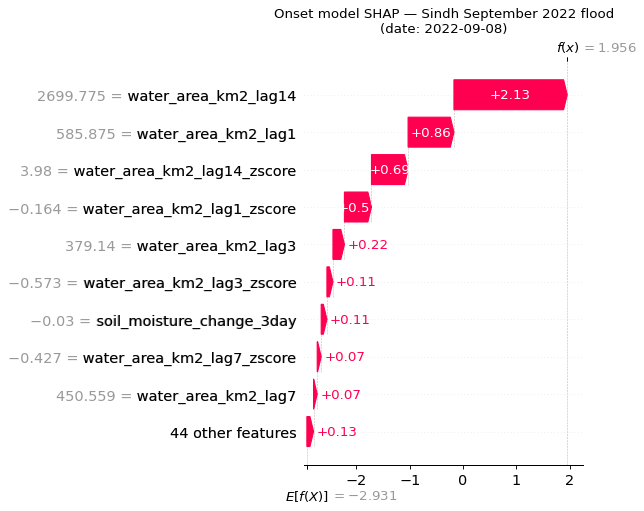

  Saved step5_plots/case_shap_Sindh_20220908.png — Sindh September 2022 flood


/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


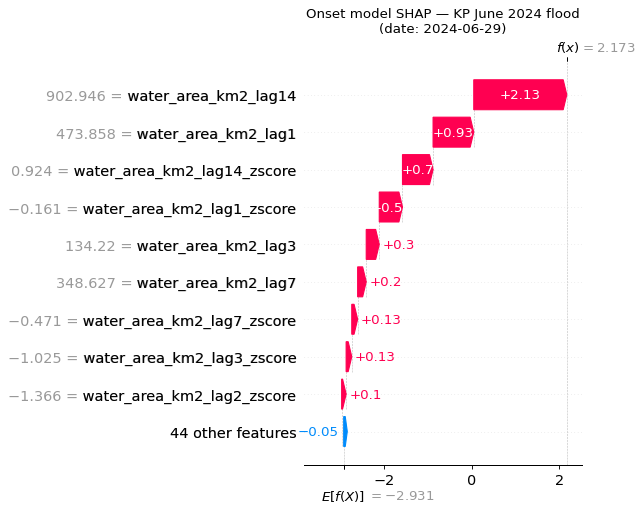

  Saved step5_plots/case_shap_KP_20240629.png — KP June 2024 flood


/home/hasnainraza/miniconda3/envs/ML/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


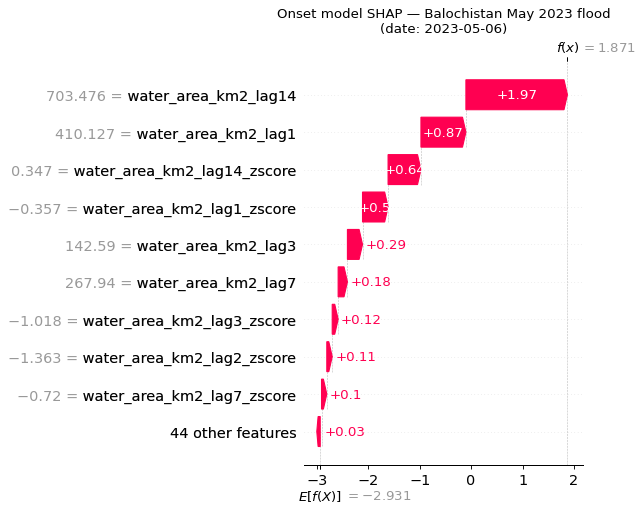

  Saved step5_plots/case_shap_Balochistan_20230506.png — Balochistan May 2023 flood


In [9]:
print("Generating SHAP waterfall plots for 3 case studies...\n")

case_studies = [
    ("Sindh_District",       pd.Timestamp("2022-09-08"), "Sindh September 2022 flood"),
    ("KP_District",          pd.Timestamp("2024-06-29"), "KP June 2024 flood"),
    ("Balochistan_District", pd.Timestamp("2023-05-06"), "Balochistan May 2023 flood"),
]

for district, date, title in case_studies:
    matching = df[(df["district"] == district) & (df["date"] == date)]
    if len(matching) == 0:
        print(f"  No data found for {title}")
        continue

    idx   = matching.index[0]
    X_row = X_all.iloc[[idx]]
    sv    = explainer_onset.shap_values(X_row)
    if isinstance(sv, list):
        sv = sv[1]

    expected = explainer_onset.expected_value
    if isinstance(expected, (list, np.ndarray)):
        expected = expected[1] if len(np.atleast_1d(expected)) > 1 else float(np.atleast_1d(expected)[0])

    explanation = shap.Explanation(
        values=sv[0],
        base_values=expected,
        data=X_row.values[0],
        feature_names=feature_cols,
    )
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=10, show=False)
    plt.title(f"Onset model SHAP — {title}\n(date: {date.date()})")
    plt.tight_layout()
    safe_name = f"{district}_{date.strftime('%Y%m%d')}".replace("_District", "")
    plt.savefig(f"{PLOTS_DIR}/case_shap_{safe_name}.png", dpi=80, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved {PLOTS_DIR}/case_shap_{safe_name}.png — {title}")

In [10]:
with open(f"{MODELS_DIR}/shap_explainer_continuation.pkl", "wb") as f:
    pickle.dump(explainer_cont, f)
with open(f"{MODELS_DIR}/shap_explainer_onset.pkl", "wb") as f:
    pickle.dump(explainer_onset, f)
with open(f"{MODELS_DIR}/feature_descriptions.pkl", "wb") as f:
    pickle.dump(FEATURE_DESCRIPTIONS, f)
with open(f"{MODELS_DIR}/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

importance_cont.to_csv(f"{MODELS_DIR}/shap_importance_continuation.csv", index=False)
importance_onset.to_csv(f"{MODELS_DIR}/shap_importance_onset.csv", index=False)

print("All Phase 2 artifacts saved.")
print(f"Plots     → {PLOTS_DIR}/")
print(f"Explainers + metadata → {MODELS_DIR}/")
print(f"  shap_explainer_continuation.pkl")
print(f"  shap_explainer_onset.pkl")
print(f"  feature_descriptions.pkl")
print(f"  feature_cols.pkl")
print(f"  shap_importance_continuation.csv")
print(f"  shap_importance_onset.csv")

All Phase 2 artifacts saved.
Plots     → step5_plots/
Explainers + metadata → final_models/
  shap_explainer_continuation.pkl
  shap_explainer_onset.pkl
  feature_descriptions.pkl
  feature_cols.pkl
  shap_importance_continuation.csv
  shap_importance_onset.csv
